In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from smooth_POD_ROM.post_processing import richardson_lucy, post_process

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.5

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"
#pth = "/home/florianma@ad.ife.no/matpro_files/Florian/results/sPODROM/"
markevery = 100

8.030570172000001


In [3]:
m = 1000
x = np.linspace(0, 1, m)

In [4]:
def plot_setup0():
    fig, ax = plt.subplots(figsize=(page_width_in/3, page_width_in/4))
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticklabels([])
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    
    plt.xlabel("x")
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.1, 1.1)
    return fig, ax

In [5]:
def approximate(A, N3):
    coefficients, _, _, _ = np.linalg.lstsq(A, N3, rcond=None)
    #print(coefficients)
    return np.sum(A*coefficients, axis=-1)

In [6]:
def f1(x, mu, w=0.1):
    # original
    y = np.zeros_like(x)
    y[np.abs(x-mu)<(w+1e-6)] = 1
    return y


def f2(x, mu):
    # moving averagee
    y = f1(x, mu)
    k = np.ones((250,))/250
    return np.convolve(y, k, mode='same')


def f3(x, mu, w=0.1, s=0.15):
    # gaussian smoothing
    y = f1(x, mu, w)
    dx = x[1]-x[0]  # 1/m
    y2 = gaussian_filter1d(y, sigma=s/dx, mode="wrap")
    return y2


def relative_error(approx, truth):
    abs_error = np.mean((approx-truth)**2)**.5
    return abs_error/np.mean((truth)**2)**.5

(<Figure size 1618.7x809.35 with 10 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


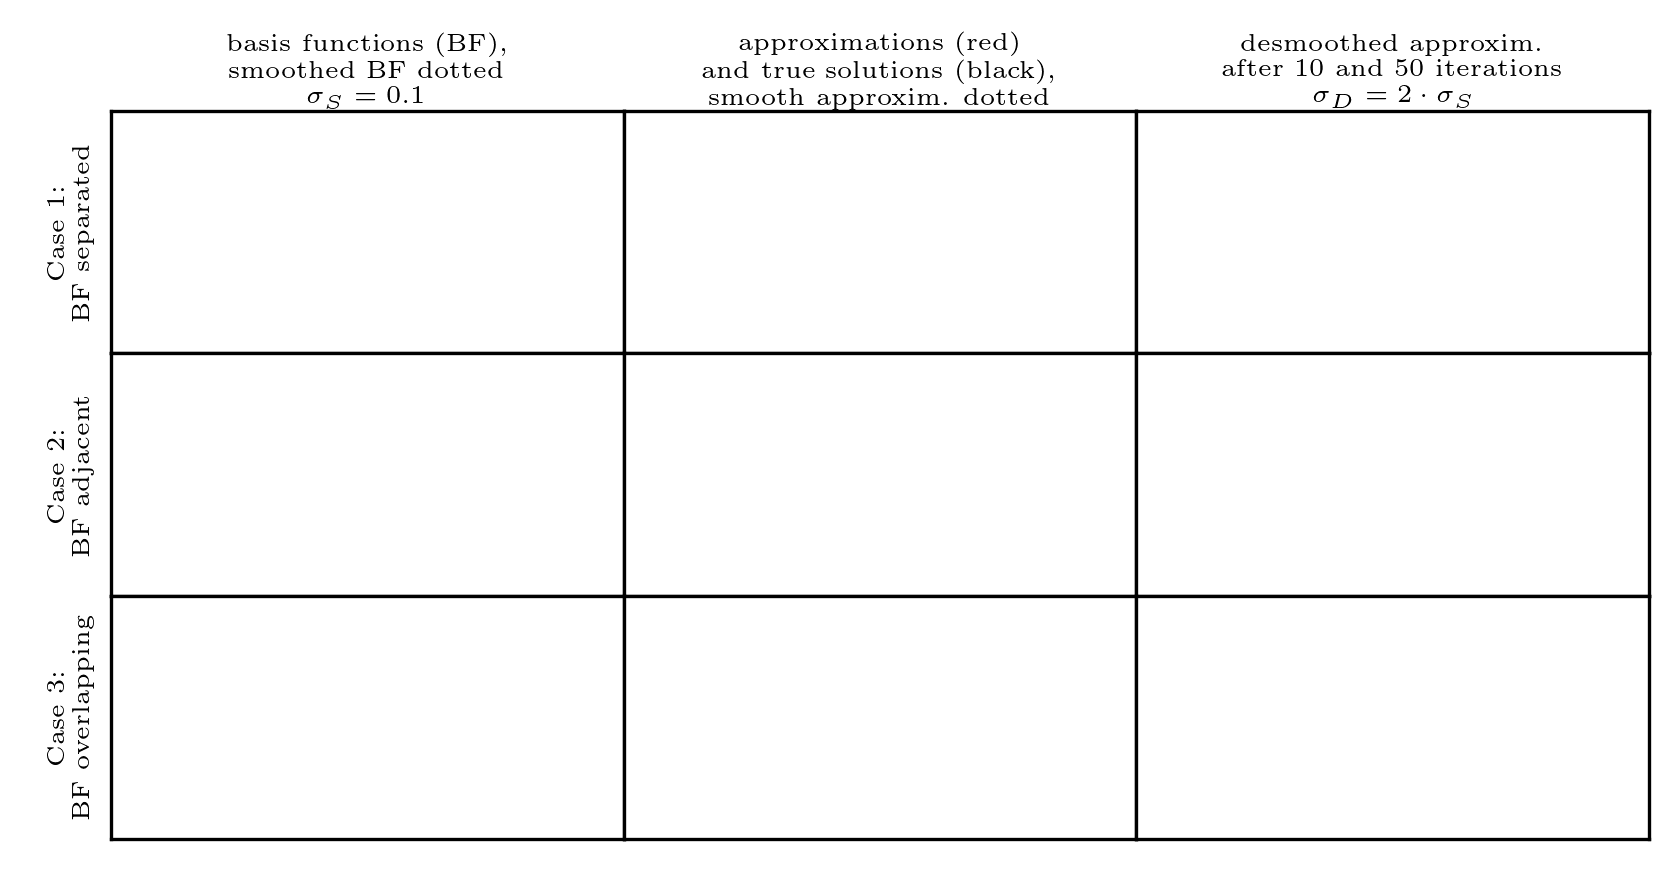

In [7]:
def small_figures():
    fig = plt.figure(figsize=(page_width_in, page_width_in/2))
    ax0 = fig.add_axes([0, 0, 1, 1])
    ax0.axis('off')
    
    nx, ny = 4, 3
    spacingw = 0.05
    spacingh = 0.1
    #w = 1/4-spacingw/4
    w = 1/3-spacingw/3
    h = 1/3-spacingh/3
    
    l1, l2, l3, l4 = 0+spacingw, 1/4+3/4*spacingw, 2/4+2/4*spacingw, 3/4+1/4*spacingw
    l1, l2, l3, l4 = 0+spacingw, 1/4*(1+3*spacingw), 1/4*(2+2*spacingw), 1/4*(3+3*spacingw)
    l1, l2, l3 = 1/3*(0+3*spacingw), 1/3*(1+2*spacingw), 1/3*(2+1*spacingw)
    b1, b2, b3 = 0, 1/3-spacingh*1/3, 2/3-spacingh*2/3
    
    ax00 = fig.add_axes([l1, b3, w, h])  # [left,bottom,width,height]
    ax01 = fig.add_axes([l2, b3, w, h])
    ax02 = fig.add_axes([l3, b3, w, h])
    #ax03 = fig.add_axes([l4, b3, w, h])
    
    ax10 = fig.add_axes([l1, b2, w, h])
    ax11 = fig.add_axes([l2, b2, w, h])
    ax12 = fig.add_axes([l3, b2, w, h])
    #ax13 = fig.add_axes([l4, b2, w, h])
    
    ax20 = fig.add_axes([l1, b1, w, h])
    ax21 = fig.add_axes([l2, b1, w, h])
    ax22 = fig.add_axes([l3, b1, w, h])
    #ax23 = fig.add_axes([l4, b1, w, h])
    
    axs = np.array([[ax00, ax01, ax02],
                    [ax10, ax11, ax12],
                    [ax20, ax21, ax22]])
    
    for ax_row in axs:
        for ax  in ax_row:
            ax.set_xticks(np.linspace(-1, 1, 5, endpoint=True), minor=False)
            ax.set_yticks(np.linspace(-1, 1, 5, endpoint=True), minor=False)
            ax.set_xticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
            ax.set_yticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
            for ticks in [ax.xaxis.get_major_ticks(), ax.xaxis.get_minor_ticks(), ax.yaxis.get_major_ticks(), ax.yaxis.get_minor_ticks()]:
                for tick in ticks:
                    tick.tick1line.set_visible(False)
                    tick.tick2line.set_visible(False)
                    tick.label1.set_visible(False)
                    tick.label2.set_visible(False)
            ax.set_xlim(-0.01, 1.01)
            ax.set_ylim(-0.1, 1.1)
    fontdict = {"ha": "center", "va":"center", "rotation": 0, "fontsize":6}
    ax0.text(l1+w/2, b3+h+spacingh/2, "basis functions (BF),\nsmoothed BF dotted\n"+r"$\sigma_S=0.1$", fontdict=fontdict)
    ax0.text(l2+w/2, b3+h+spacingh/2, "approximations (red)\nand true solutions (black),\nsmooth approxim. dotted", fontdict=fontdict)
    #ax0.text(5/8+spacingw/4*2, b3+h+spacingh/2, "desmoothed approxim.\nafter 10 and 50 iterations\n$\sigma_D=\sigma_S$", fontdict=fontdict)
    ax0.text(l3+w/2, b3+h+spacingh/2, "desmoothed approxim.\nafter 10 and 50 iterations\n"+r"$\sigma_D=2\cdot\sigma_S$", fontdict=fontdict)
    
    fontdict["rotation"] = 90
    ax0.text(spacingw/2, h*5/2, "Case 1:\nBF separated", fontdict=fontdict)
    ax0.text(spacingw/2, h*3/2, "Case 2:\nBF adjacent", fontdict=fontdict)
    ax0.text(spacingw/2, h/2, "Case 3:\nBF overlapping", fontdict=fontdict)
    return fig, axs
small_figures()

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:24: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


0.935 &0.804 &0.541 &0.221 &\\
0.707 &0.650 &0.348 &0.201 &\\
0.500 &0.547 &0.304 &0.129 &\\


C:\Users\florianma\AppData\Local\Temp\ipykernel_18212\453951924.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(pth+"example1.pdf")


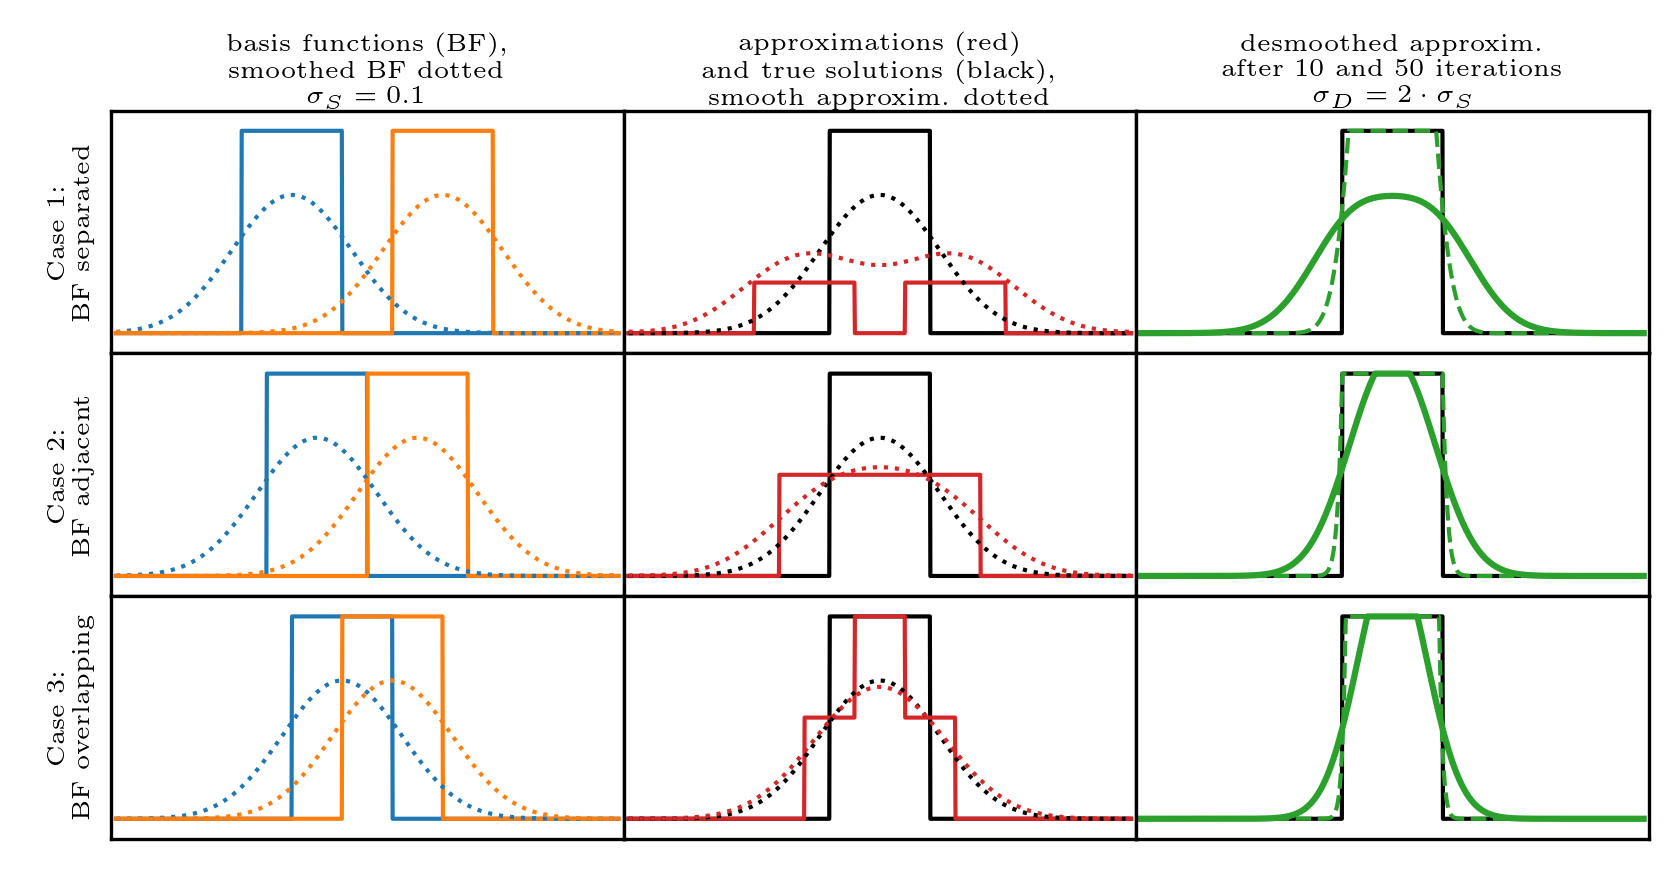

In [8]:
def new_small_figure():
    fig, ax = plt.subplots(1, 1, figsize=(page_width_in/4, page_width_in/4))
    ax.set_xticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
    ax.set_yticklabels([])
    ax.grid(True, which='minor', linestyle='--', lw=.25)
    ax.grid(True, which='major', linestyle='-')
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.1, 1.1)
    return fig, ax


sig = 0.1

# for an error < 1% in case 3, choose sigma = 0.04 and num_iter=1000

fig, axs = small_figures()
for case, d, row in zip(["separated", "adjacent", "overlapping"],
                                    [0.15, 0.1, 0.05], [0, 1, 2]):
    N1 = f1(x, 0.5-d, w=0.1)
    N2 = f1(x, 0.5+d, w=0.1)
    N3 = f1(x, 0.5, w=0.1)
    #print("x1, x2=", 0.5-d, 0.5+d)
    
    A = np.vstack([N1, N2]).T
    N3_hat = approximate(A, N3)
    
    N1_s = f3(x, 0.5-d, w=0.1, s=sig)
    N2_s = f3(x, 0.5+d, w=0.1, s=sig)
    N3_s = f3(x, 0.5, w=0.1, s=sig)
    A = np.vstack([N1_s, N2_s]).T
    N3_s_hat = approximate(A, N3_s)

#     N3_D30_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=10, truth=None, damping=2, clip=True, mode="wrap")
#     N3_D50_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=50, truth=None, damping=2, clip=True, mode="wrap")
#     N3_D100_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=100, truth=None, damping=2, clip=True, mode="wrap")
    
    N3_D30 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=10, truth=None, damping=2, clip=True, mode="wrap")
    N3_D50 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=50, truth=None, damping=2, clip=True, mode="wrap")
    N3_D100 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=100, truth=None, damping=2, clip=True, mode="wrap")

    for N3_hat_xy in [N3_hat, N3_s_hat, N3_D30, N3_D100]:
        e = (np.mean((N3_hat_xy-N3)**2)**.5) / np.mean(N3**2)**.5
        print("{:.3f}".format(e), end=" &")
    print("\\\\")

    axs[row, 0].plot(x, N1, "C0", lw=1, label="$N_1$")
    axs[row, 0].plot(x, N2, "C1", lw=1, label="$N_2$")
    axs[row, 0].plot(x, N1_s, "C0:", lw=1, label="$N_{1,S}$")
    axs[row, 0].plot(x, N2_s, "C1:", lw=1, label="$N_{2,S}$")

    axs[row, 1].plot(x, N3, "k-", lw=1, label="$N_3$")
    axs[row, 1].plot(x, N3_hat, "C3-", lw=1, label=r"$\widehat{N}_3$")
    axs[row, 1].plot(x, N3_s, "k:", lw=1, label="$N_{3,S}$")
    axs[row, 1].plot(x, N3_s_hat, "C3:", lw=1, label=r"$\widehat{N}_{3,S}$")
    
#     axs[row, 2].plot(x, N3, "k-", lw=1, label="$N_3$")
#     axs[row, 2].plot(x, N3_D30_, "C4-", lw=1, label="$\widehat{N}_{3,D_{30}}$")
#     #axs[row, 2].plot(x, N3_D50_, "C4--", lw=1, label="$\widehat{N}_{3,D_{50}}$")
#     axs[row, 2].plot(x, N3_D100_, "C4--", lw=1, label="$\widehat{N}_{3,D_{100}}$")
    
    axs[row, 2].plot(x, N3, "k-", lw=1, label="$N_3$")
    axs[row, 2].plot(x, N3_D30, "C2-", label=r"$\widehat{N}_{3,D_{30}}$")
    #axs[row, 2].plot(x, N3_D50, "C2--", lw=1, label="$\widehat{N}_{3,D_{50}}$")
    axs[row, 2].plot(x, N3_D100, "C2--", lw=1, label=r"$\widehat{N}_{3,D_{100}}$")
plt.savefig(pth+"example1.pdf")
plt.show()
    


In [9]:
# c, num_iter = 1.8, 130  # e= 0.118678
# eo = 1
# for c in np.linspace(1, 3, 21):
#     for num_iter in np.arange(10, 500, 10):
#         N3_D500 = richardson_lucy(x, N3_s_hat, sgm=sig*c, num_iter=num_iter, truth=None, damping=2, clip=True, mode="wrap")
#         e = (np.mean((N3_D500-N3)**2)**.5) / np.mean(N3**2)**.5
#         if e < eo:
#             print(c, num_iter, "{:.6f}".format(e), sep="\t")
#             eo = e

In [10]:
n_ds = 1000
m = 1000
x = np.linspace(0, 1, m)

distances = np.linspace(0, 0.15, n_ds)
sigmas = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.1]
n_sigmas = len(sigmas)
e1 = np.zeros(n_ds,)
e2 = np.zeros((n_ds, n_sigmas),)
e3 = np.zeros((n_ds, n_sigmas),)
e4 = np.zeros((n_ds, n_sigmas),)
e5 = np.zeros((n_ds, n_sigmas),)
for i, d in enumerate(distances):
    print(i, end=", ")
    N1 = f1(x, 0.5-d, w=0.1)
    N2 = f1(x, 0.5+d, w=0.1)
    N3 = f1(x, 0.5, w=0.1)
    A = np.vstack([N1, N2]).T
    N3_hat = approximate(A, N3)
    e1[i] = np.mean((N3_hat-N3)**2)**.5
    e_min = 100
    sig_opt = 0
    for j, sig in enumerate(sigmas):
        N1_s = f3(x, 0.5-d, w=0.1, s=sig)
        N2_s = f3(x, 0.5+d, w=0.1, s=sig)
        N3_s = f3(x, 0.5, w=0.1, s=sig)
        A = np.vstack([N1_s, N2_s]).T
        N3_s_hat = approximate(A, N3_s)
#         N3_D30_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=10, truth=None, damping=10, clip=True, mode="wrap")
#         N3_D100_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=50, truth=None, damping=10, clip=True, mode="wrap")
#         N3_D30 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=10, truth=None, damping=10, clip=True, mode="wrap")
        N3_D100 = richardson_lucy(x, N3_s_hat, sgm=sig*2.0, num_iter=1000, truth=None, damping=2, clip=True, mode="wrap")
#         e2[i, j] = np.mean((N3_s_hat-N3)**2)**.5
        e3[i, j] = np.mean((N3_s_hat-N3_s)**2)**.5
#         e4[i, j] = np.mean((N3_D30-N3)**2)**.5
        e5[i, j] = np.mean((N3_D100-N3)**2)**.5

0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 

<>:16: SyntaxWarning: invalid escape sequence '\|'
<>:16: SyntaxWarning: invalid escape sequence '\|'
C:\Users\florianma\AppData\Local\Temp\ipykernel_18212\3554175263.py:16: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel("$\|\widehat{N}_{3,D_{1000}}-N_3\|_{L_2}$")


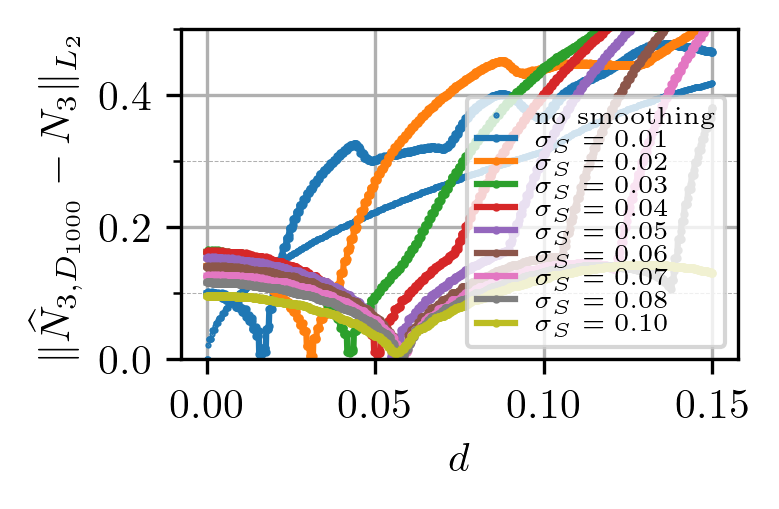

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

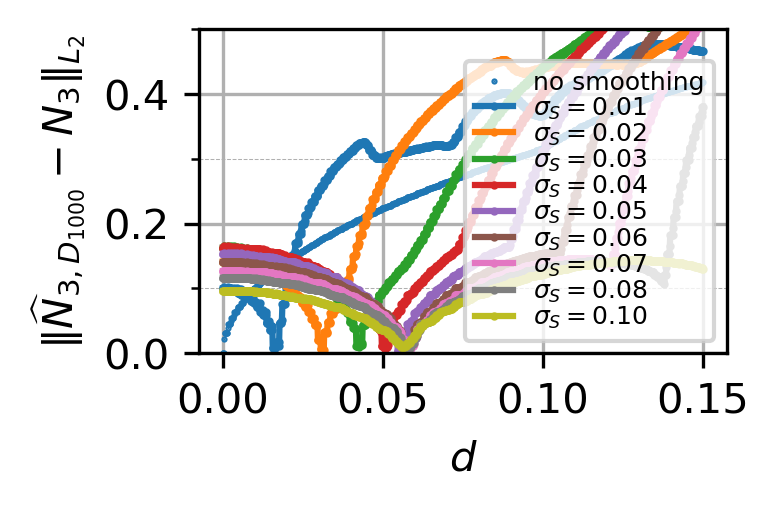

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(page_width_in/2, page_width_in/3))

ax.plot(distances, e1, "C0.", ms=1, label="no smoothing")
for j, sig in enumerate(sigmas[:9]):
    ax.plot(distances, e5[:, j], "o-", ms=1, label=r"$\sigma_S={:.2f}$".format(sig))

#ax.set_xticks(np.linspace(0, .15, 16, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
#ax.set_yticklabels([])
ax.legend()
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')

plt.xlabel("distance $d$ between $N_1$ and $N_2$")
plt.xlabel("$d$")
plt.ylabel("$\|\widehat{N}_{3,D_{1000}}-N_3\|_{L_2}$")
#plt.xlim(0, 3.)
plt.ylim(0, 0.5)
plt.savefig(pth+"example1_e_vs_d.pdf")
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\|'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\|'
C:\Users\florianma\AppData\Local\Temp\ipykernel_18212\1580744146.py:5: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(distances/sig, e5[:, j], "o-", ms=1, label="$\sigma_S={:.2f}$".format(sig))
C:\Users\florianma\AppData\Local\Temp\ipykernel_18212\1580744146.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("$d/\sigma_S$")
C:\Users\florianma\AppData\Local\Temp\ipykernel_18212\1580744146.py:16: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel("$\|\widehat{N}_{3,D_{1000}}-N_3\|_{L_2}$")


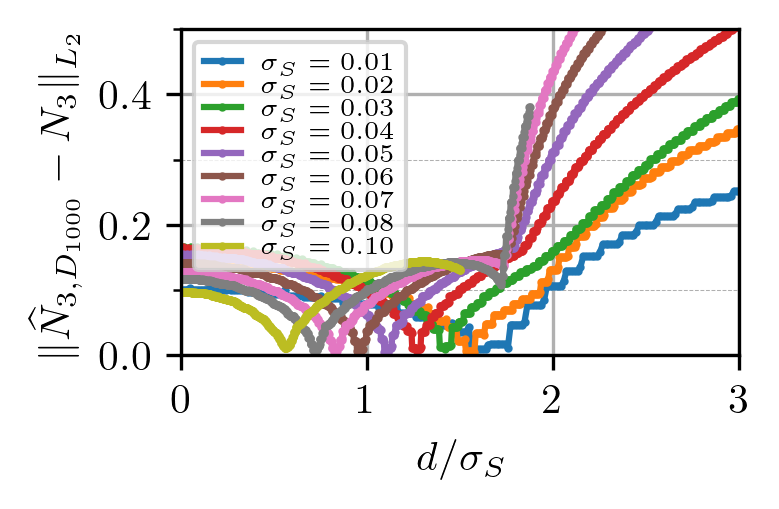

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

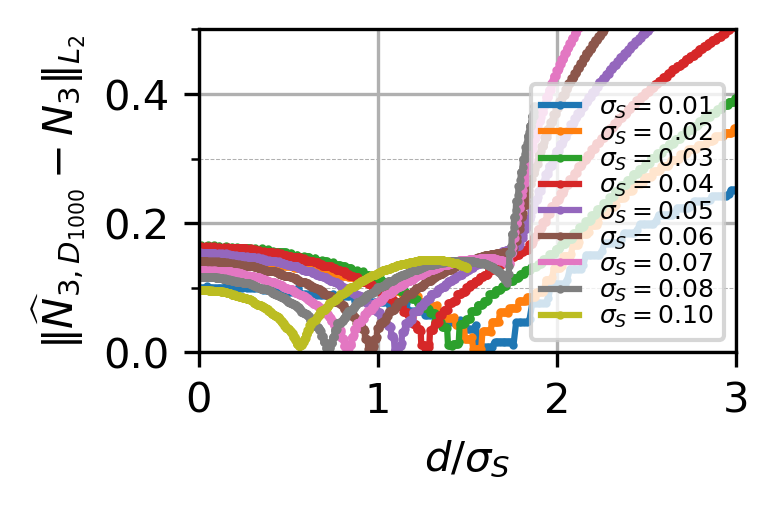

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(page_width_in/2, page_width_in/3))

#ax.plot(distances, e1, "C0.", ms=1, label="no smoothing")
for j, sig in enumerate(sigmas[:9]):
    ax.plot(distances/sig, e5[:, j], "o-", ms=1, label="$\sigma_S={:.2f}$".format(sig))

#ax.set_xticks(np.linspace(0, .15, 16, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
#ax.set_yticklabels([])
ax.legend()
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')

plt.xlabel("distance $d$ between $N_1$ and $N_2$")
plt.xlabel("$d/\sigma_S$")
plt.ylabel("$\|\widehat{N}_{3,D_{1000}}-N_3\|_{L_2}$")
plt.xlim(0, 3.)
plt.ylim(0, 0.5)
plt.savefig(pth+"example1_e_vs_d.pdf")
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(page_width_in/2, page_width_in/3))

#ax.plot(distances, e1, "C0.", ms=1, label="no smoothing")
for j, sig in enumerate(sigmas[:9]):
    ax.plot(distances/sig, e5[:, j], "o-", ms=1, label=r"$\sigma_S={:.2f}$".format(sig))

#ax.set_xticks([0.3, 1, 3], labels=[0.3, 1, 3], minor=True)
#ax.set_xticks([0.3, 1, 3], labels=[0.3, 1, 3], minor=False)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
#ax.set_yticklabels([])
#ax.legend()
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')

plt.xlabel("distance $d$ between $N_1$ and $N_2$")
plt.xlabel(r"$d/\sigma_S$")
plt.ylabel(r"$\|\widehat{N}_{3,D_{1000}}-N_3\|_{L_2}$")
plt.xlim(0.3, 3.)
plt.ylim(0.001, 0.5)
#ax.set_xticks([0.3, 1, 3], major=True)
ax.set_xscale('log')
ax.set_yscale('log')
plt.xticks([0.3, 1, 3])
ax.set_xticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1,2, 3], labels=[0.3, "", "", "", "", "", "", 1, "", 3], minor=False)
plt.savefig(pth+"example1_e_vs_dloglog.pdf")
plt.show()

In [14]:
# a = np.arange(20)
# np.random.shuffle(a)
# a[:5]
# np.random.rand(n)

In [15]:
m2 = 300  # numerb samples in x
x2 = np.linspace(0, 1, m2)
N_max = 150 # max rank
ns = 50  # n samples of N_3 to test
n_trials = 5
_sima_ = 0.015
_sima2_ = 0.03


X_tst1 = np.empty((m2, ns))
X_tst2 = np.empty((m2, ns))
X_tst3 = np.empty((m2, ns))
mus = np.linspace(0, 1, ns, endpoint=False)+1/(2*ns)
for j, mu in enumerate(mus):
    X_tst1[:, j] = f1(x2, mu, w=0.01)
    X_tst2[:, j] = f3(x2, mu, w=0.01, s=_sima_)
    X_tst3[:, j] = f3(x2, mu, w=0.01, s=_sima2_)
e0_1 = np.mean(np.mean((X_tst1)**2, axis=0)**.5)
e0_2 = np.mean(np.mean((X_tst2)**2, axis=0)**.5)
e0_3 = np.mean(np.mean((X_tst3)**2, axis=0)**.5)

NN = np.arange(1, N_max, 1)
eN1 = np.zeros((len(NN), n_trials))
eN2 = np.zeros((len(NN), n_trials))-1
eN3 = np.zeros((len(NN), n_trials))-1
eN4 = np.zeros((len(NN), n_trials))-1
eN5 = np.zeros((len(NN), n_trials))-1

#mu_rnd_all = x2.copy()#[::2]

for i, n in enumerate(NN):
    for trial in range(n_trials):
        basis1 = np.empty((m2, n))
        basis2 = np.empty((m2, n))
        basis3 = np.empty((m2, n))
        
#         # random, but unique BF
#         np.random.shuffle(mu_rnd_all)
#         mu_rnd = mu_rnd_all[:n]
        mu_rnd = np.random.rand(n)
        
        for j, mu_j in enumerate(mu_rnd):
            basis1[:, j] = f1(x2, mu_j, w=0.01)
            basis2[:, j] = f3(x2, mu_j, w=0.01, s=_sima_)
            basis3[:, j] = f3(x2, mu_j, w=0.01, s=_sima2_)
        
        coefficients1 = np.zeros((n, ns))
        coefficients2 = np.zeros((n, ns))
        coefficients3 = np.zeros((n, ns))

        for j, mu in enumerate(mus):
            coefficients1[:, j], _, _, _ = np.linalg.lstsq(basis1, X_tst1[:, j], rcond=None)
            coefficients2[:, j], _, _, _ = np.linalg.lstsq(basis2, X_tst2[:, j], rcond=None)
            coefficients3[:, j], _, _, _ = np.linalg.lstsq(basis3, X_tst3[:, j], rcond=None)
        approximations1 = basis1 @ coefficients1
        approximations2 = basis2 @ coefficients2
        approximations3 = basis3 @ coefficients3
        #if trial==0 and i%2 == 0:
        approximations2DS = post_process(x2, approximations2, _sima_, c=1.0, mu_test=mus[:, None],
                                       mu_train=mu_rnd[:, None], num_iter=200,
                                       shape=(m2,), clip=True, progress=False)
        approximations3DS = post_process(x2, approximations3, _sima2_, c=1.0, mu_test=mus[:, None],
                                       mu_train=mu_rnd[:, None], num_iter=200,
                                       shape=(m2,), clip=True, progress=False)
        #print(e3[i], e3[i]/e0_1)
        eN1[i, trial] = np.mean(np.mean((approximations1-X_tst1)**2, axis=0)**.5)
        eN2[i, trial] = np.mean(np.mean((approximations2-X_tst1)**2, axis=0)**.5)
        eN3[i, trial] = np.mean(np.mean((approximations3-X_tst1)**2, axis=0)**.5)
        eN4[i, trial] = np.mean(np.mean((approximations2DS-X_tst1)**2, axis=0)**.5)
        eN5[i, trial] = np.mean(np.mean((approximations3DS-X_tst1)**2, axis=0)**.5)
#         for k in range(ns):
#             fig, ax = plt.subplots()
#             ax.plot(x, X_tst1[:, k])
#             ax.plot(x, X_tst2[:, k])
#             ax.plot(x, approximations1[:, k])
#             ax.plot(x, approximations2[:, k])
#             ax.plot(x, approximations3[:, k])
#             plt.show()
    print(n, np.median(eN1[i, :])/e0_1, np.median(eN2[i, :])/e0_2,  np.median(eN4[i, :])/e0_1)
# 10: 0.37
# 50: 0.15
# 100: 0.065
# 200: 0.047
# 500: 0.045
# 1000: 0.046

pp 0.015 1.0 200 (300,) True


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:24: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
1 0.9907756819115168 1.667654020721355 1.0032504124614854
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
2 0.9845389825931565 1.6506378561702353 1.0028546438053483
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
3 0.9791799987445341 1.6336243702520576 1.009037812770689

pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
49 0.6328576233506098 1.1425629200233174 0.14457154925172505
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
50 0.6507848762930548 1.1582123381671108 0.1939173617580729
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
51 0.6485859024758307 1.

pp 0.03 1.0 200 (300,) True
72 0.553077735359897 1.1060749497706777 0.06103431535714624
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
73 0.5389897924016067 1.0976708345848571 0.04969004077793464
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
74 0.526408510934529 1.1025992547001608 0.07371190623985745
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,

pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
96 0.4510797601669314 1.0881951769972575 0.0370181546591188
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
97 0.4423236244714889 1.0875622807500018 0.03636430494961447
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
98 0.4174654384842443 1.087956415870748 0.037814033522588324
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300

pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
120 0.37715936470011735 1.0874756683707323 0.036228871519448744
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
121 0.37364649740493144 1.0881519687209813 0.03673490019673255
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
122 0.382766072084

pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
143 0.321805029891985 1.0874731307442422 0.036334967961935465
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
144 0.3143138320484921 1.0874722457390948 0.03692900052080538
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
145 0.29324132793596985 1.0874712682191556 0.03740586724814213
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 200 (300,) True
pp 0.03 1.0 200 (300,) True
pp 0.015 1.0 20

In [16]:
# print(eN1.shape, NN.shape)
# np.save(pth+"/NN.npy", NN)
# np.save(pth+"/eN1.npy", eN1)
# np.save(pth+"/eN2.npy", eN2)
# np.save(pth+"/eN3.npy", eN3)

# # NN = np.load(pth+"/NN.npy")
# # eN1 = np.load(pth+"/eN1.npy")
# # eN2 = np.load(pth+"/eN2.npy")
# # eN3 = np.load(pth+"/eN3.npy")
# # e0_1 = np.mean(np.mean((X_tst1)**2, axis=0)**.5)
# # e0_2 = np.mean(np.mean((X_tst2)**2, axis=0)**.5)

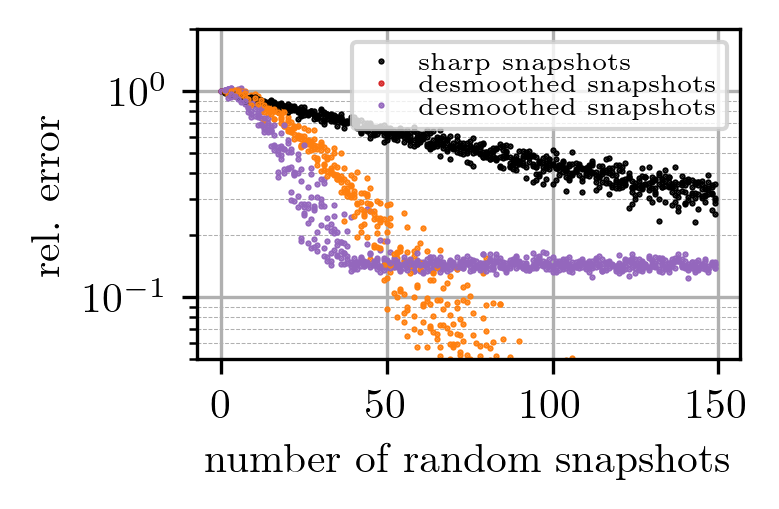

[98.86205455 98.07553391 97.60647735 96.85553203 95.0870767  93.52296895
 93.30232593 92.55183532 92.49882948 91.17718171 90.63986928 89.48381555
 88.45762048 87.3682444  87.77582884 87.81878322 83.72292643 85.85254384
 83.96093107 83.83207995 82.66560622 82.90592416 79.5863316  79.32535065
 80.34142468 78.21526011 79.68082505 77.34313334 75.32042781 77.84780482
 74.25612911 76.28573292 74.95212153 73.83223058 72.99987211 74.06867504
 70.15179282 71.31472063 72.30992751 71.55941661 69.57350548 65.77232707
 67.44623866 66.75929522 65.57239492 64.01060428 65.58182211 66.38272527
 63.16867776 62.13294688 64.11667701 61.48228816 61.63393081 63.7659728
 60.65944367 61.62562951 58.81369274 61.78913652 58.52602788 59.23363534
 60.4350964  59.63690838 56.12296372 57.32914427 57.05714376 57.2864876
 56.69196112 55.29287147 54.03467044 53.9252342  55.50895169 53.84532053
 53.19326539 51.23758299 52.67388712 51.66114797 52.5075587  52.52045127
 51.74974764 49.50464383 49.26990252 50.47842954 49.3

In [17]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(0, e0_1/e0_1, "k.", ms=1, label="sharp snapshots")
# ax.plot(0, e0_2/e0_2, "C1.", ms=1, label="smoothed snapshots")
# ax.plot(0, e0_2/e0_2, "C2.", ms=1, label="smoothed snapshots")
ax.plot(0, e0_1/e0_1, "C3.", ms=1, label="desmoothed snapshots")
ax.plot(0, e0_1/e0_1, "C4.", ms=1, label="desmoothed snapshots")

for trial in range(n_trials):
    ax.plot(NN, eN1[:, trial]/e0_1, "k.", ms=1)
#     ax.plot(NN, eN2[:, trial]/e0_1, "C1.", ms=1)
#     ax.plot(NN, eN3[:, trial]/e0_1, "C2.", ms=1)
    ax.plot(NN, eN4[:, trial]/e0_1, "C1.", ms=1)
    ax.plot(NN, eN5[:, trial]/e0_1, "C4.", ms=1)
#    ax.plot(NN, e3[:, trial]/e0_1, "C2.", ms=1)
# ax.plot(np.r_[0, NN], np.r_[1, np.median(e1/e0_1, axis=-1)], "k--", lw=1)
# ax.plot(np.r_[0, NN], np.r_[1, np.median(e2/e0_2, axis=-1)], "C1--", lw=1)
# ax.plot(np.r_[0, NN], np.r_[1, np.median(e3/e0_1, axis=-1)], "C2--", lw=1)
#ax.plot(NN, np.mean(e3/e0_1, axis=-1), "C2--", ms=1)

ax.grid()
#ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_xticks(np.linspace(0, 100, 11, endpoint=True), minor=True)
#ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
#ax.grid(True, which='both')
ax.set_ylim([5e-2, 2])
#ax.set_xlim([0, 510])
#ax.set_xlim([10, 100])
#ax.set_xticklabels(["", "10", "20", "30", "", "50", "", "", "", "", "100"], minor=True)
ax.set_xlabel("number of random snapshots")
ax.set_ylabel("rel. error")
plt.legend()

plt.savefig(pth+"1st_ex_decay_v3.pdf")
plt.show()
np.set_printoptions(suppress=True)
print(np.mean(eN1/e0_1, axis=-1)*100)
print(np.mean(eN2/e0_2, axis=-1)*100)


In [18]:
asd

NameError: name 'asd' is not defined

ValueError: x and y must have same first dimension, but have shapes (1000,) and (300,)

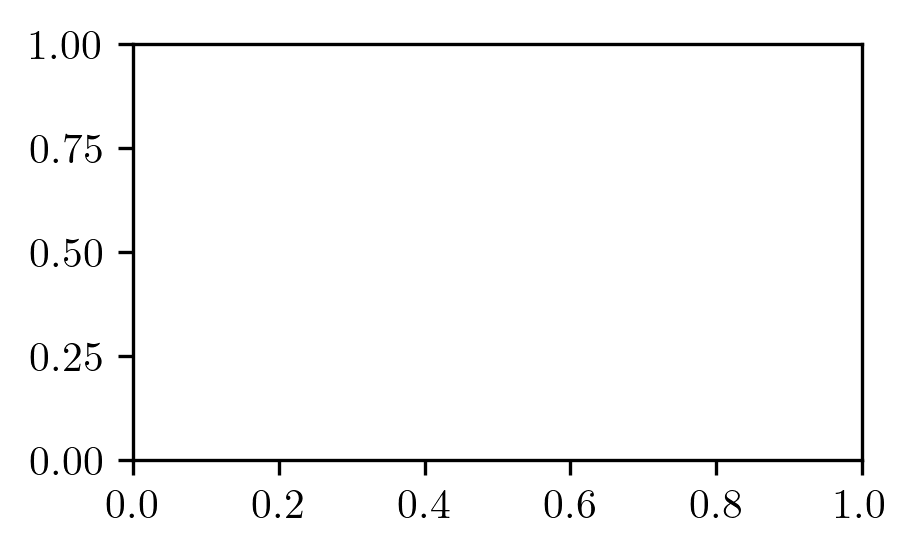

In [20]:
for j, mu in enumerate(mus):
    if j%15 == 0:
        plt.plot(x, X_tst1[:, j])
        plt.plot(x, X_tst2[:, j], ls="--")

In [21]:
np.logspace(-6, 1, 5, endpoint=True)

array([ 0.000001  ,  0.00005623,  0.00316228,  0.17782794, 10.        ])

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

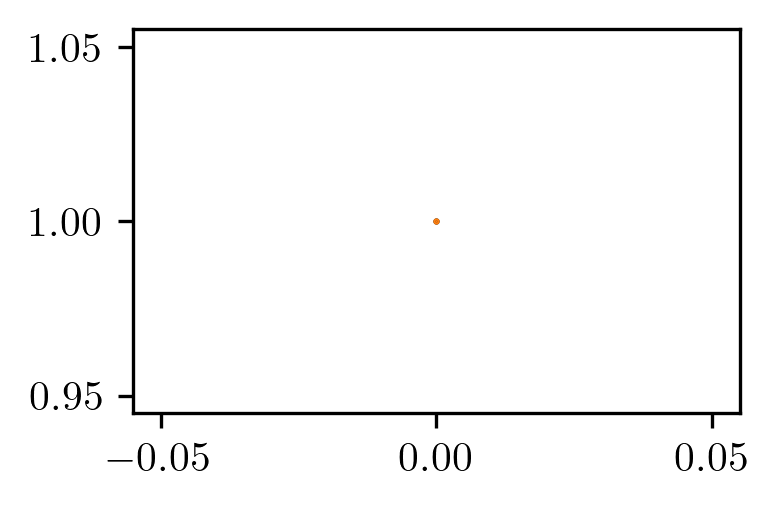

In [22]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(0, e0_1/e0_1, "k.", ms=1)
ax.plot(0, e0_2/e0_2, "C1.", ms=1)

for trial in range(n_trials):
    ax.plot(NN, e1[:, trial]/e0_1, "k.", ms=1)
    ax.plot(NN, e2[:, trial]/e0_2, "C1.", ms=1)
#    ax.plot(NN, e3[:, trial]/e0_1, "C2.", ms=1)
ax.plot(np.r_[0, NN], np.r_[1, np.median(e1/e0_1, axis=-1)], "k--", ms=1)
ax.plot(np.r_[0, NN], np.r_[1, np.median(e2/e0_2, axis=-1)], "C1--", ms=1)
#ax.plot(NN, np.mean(e3/e0_1, axis=-1), "C2--", ms=1)

ax.grid()
ax.set_xlim([-5, 205])
ax.set_ylim([1e-6, 2])
ax.set_yscale('log')
ax.set_xticks(np.linspace(0, 200, 21, endpoint=True), minor=True)
ax.set_yticks(np.logspace(-6, 0, 7, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.show()
np.set_printoptions(suppress=True)
print(np.mean(e1/e0_1, axis=-1)*100)
print(np.mean(e2/e0_2, axis=-1)*100)

In [ ]:
asd

In [ ]:
approximations *= 0
e = np.mean((X_tst)**2, axis=0)**.5
print(e)
print(n, np.mean(e))

In [ ]:
asd

In [23]:
def pulse(x, mu, w=0.1+1e-6):
    y = np.zeros_like(x, dtype=np.float64)
    y[((0+1e-6) < (x-mu)) & ((x-mu) < (w-1e-6))] = 1.0
    mu2 = mu+1
    y[((0+1e-6) < (x-mu2)) & ((x-mu2) < (w-1e-6))] = -1.0
    mu3 = mu-1
    y[((0+1e-6) < (x-mu3)) & ((x-mu3) < (w-1e-6))] = -1.0
    mu4 = mu-2
    y[((0+1e-6) < (x-mu4)) & ((x-mu4) < (w-1e-6))] = 1.0
    return y

from smooth_POD_ROM.pre_processing import smoothen

<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
C:\Users\florianma\AppData\Local\Temp\ipykernel_18212\2255365856.py:45: SyntaxWarning: invalid escape sequence '\m'
  axg1.plot(x, Ug[:, 0], ".-", ms=1, label="$n_{\mu}=%i$"%n)
C:\Users\florianma\AppData\Local\Temp\ipykernel_18212\2255365856.py:46: SyntaxWarning: invalid escape sequence '\m'
  axs1.plot(x, Us[:, 0], ".-", ms=1, label="$n_{\mu}=%i$"%n)
C:\Users\florianma\AppData\Local\Temp\ipykernel_18212\2255365856.py:47: SyntaxWarning: invalid escape sequence '\m'
  axg2.plot(x, Ug[:, 1], ".-", ms=1, label="$n_{\mu}=%i$"%n)
C:\Users\florianma\AppData\Local\Temp\ipykernel_18212\2255365

-0.9995 1.9995
0.0004999999999999449 0.0004999999999999449
mu
0.0 1.8
0.0 0.19999999999999996
10
-0.9995 1.9995
0.0004999999999999449 0.0004999999999999449
mu
0.0 1.9000000000000001
0.0 0.09999999999999987
20
-0.9995 1.9995
0.0004999999999999449 0.0004999999999999449
mu
0.0 1.9333333333333333
0.0 0.06666666666666665
30
-0.9995 1.9995
0.0004999999999999449 0.0004999999999999449
mu
0.0 1.998
0.0 0.0020000000000000018
1000


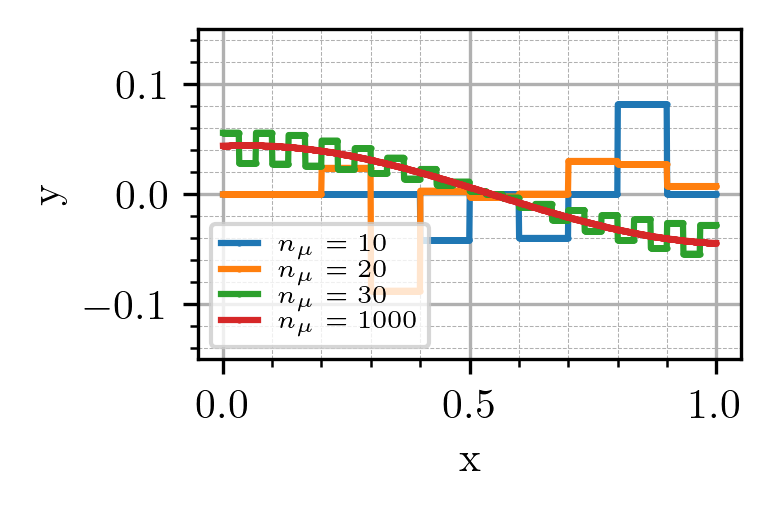

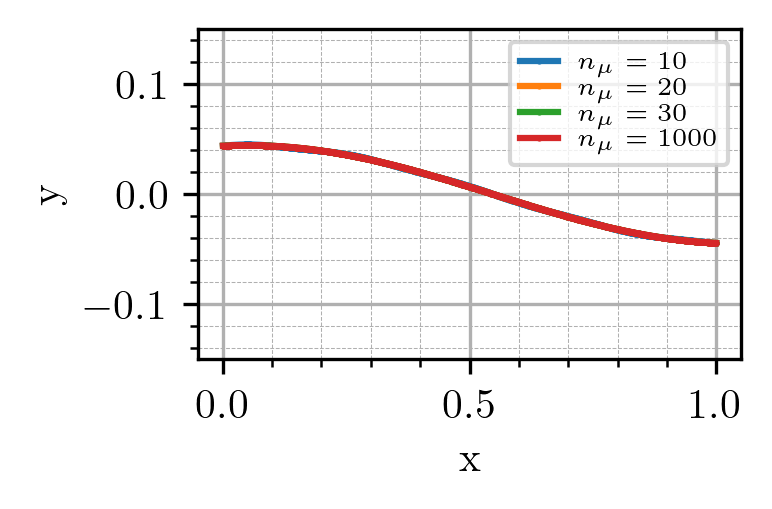

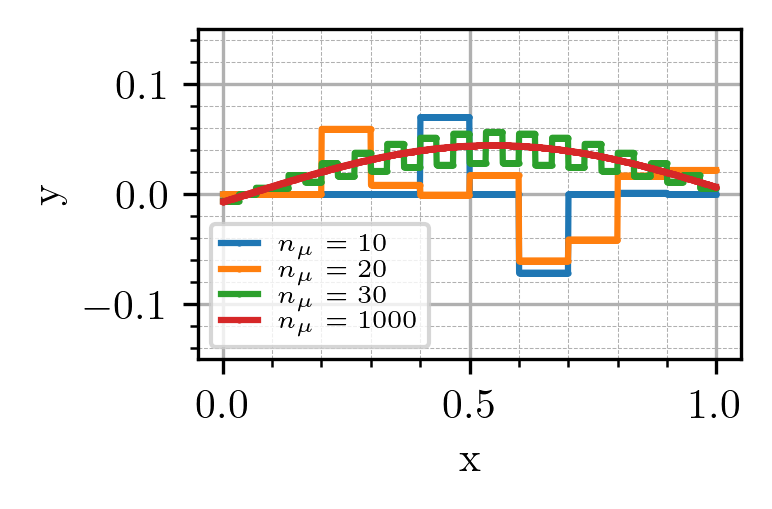

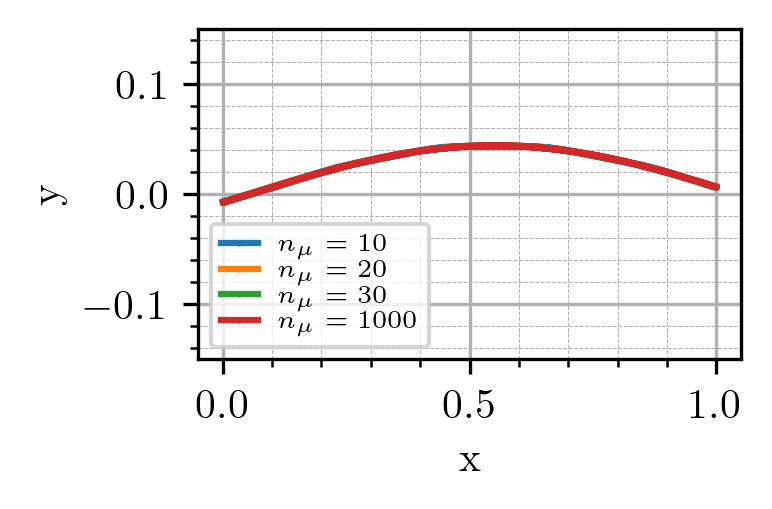

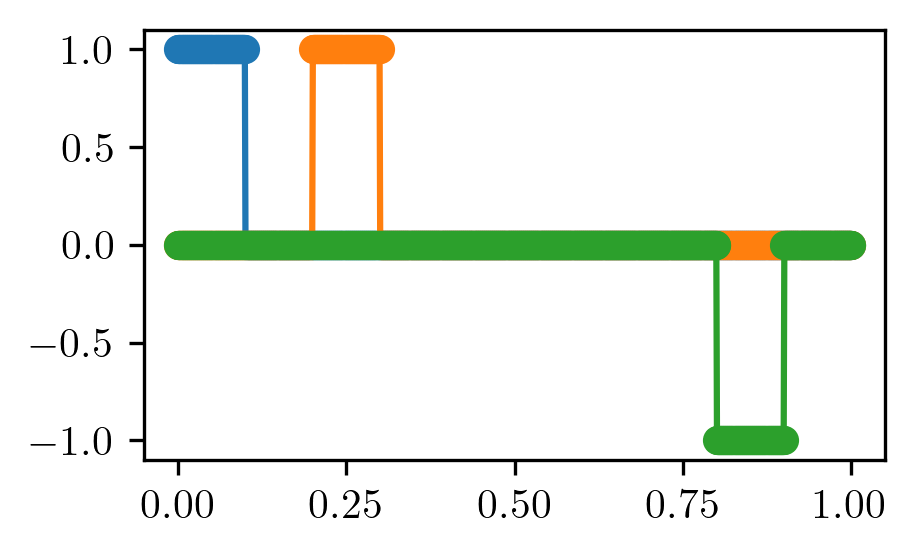

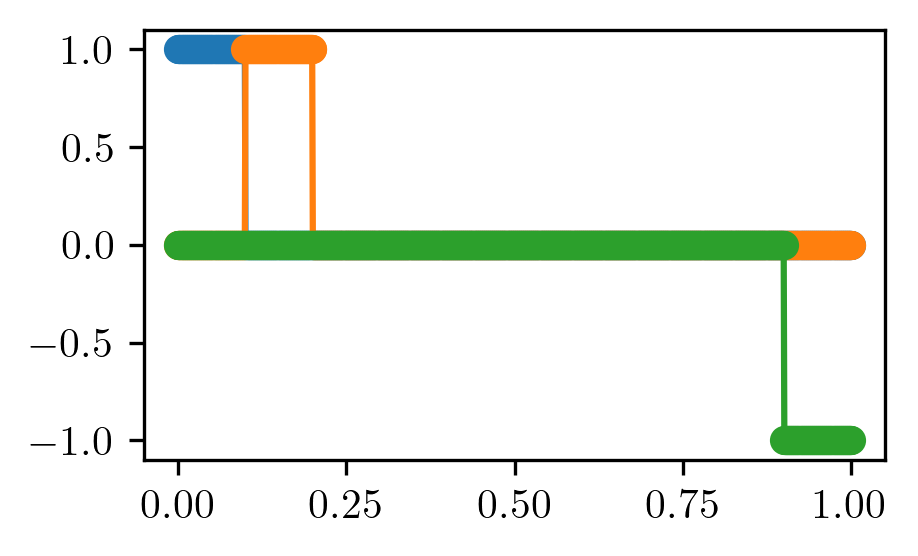

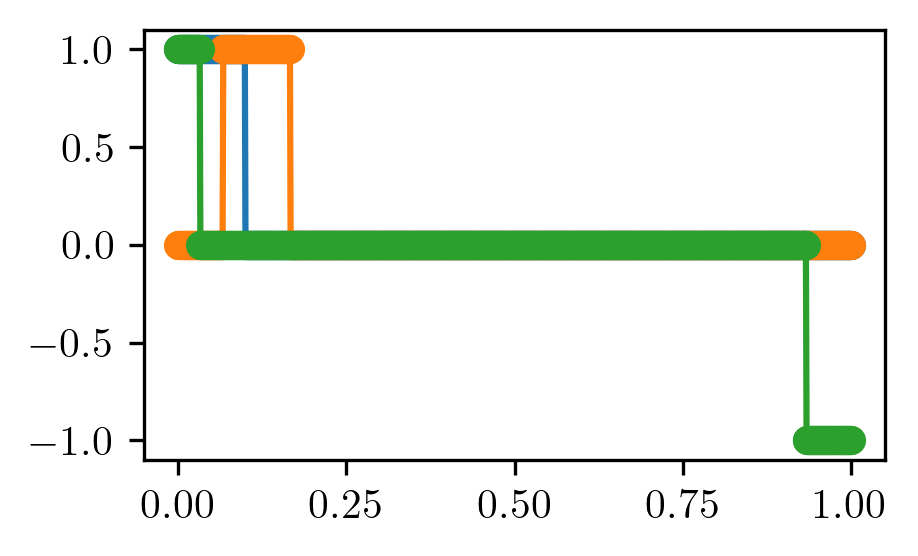

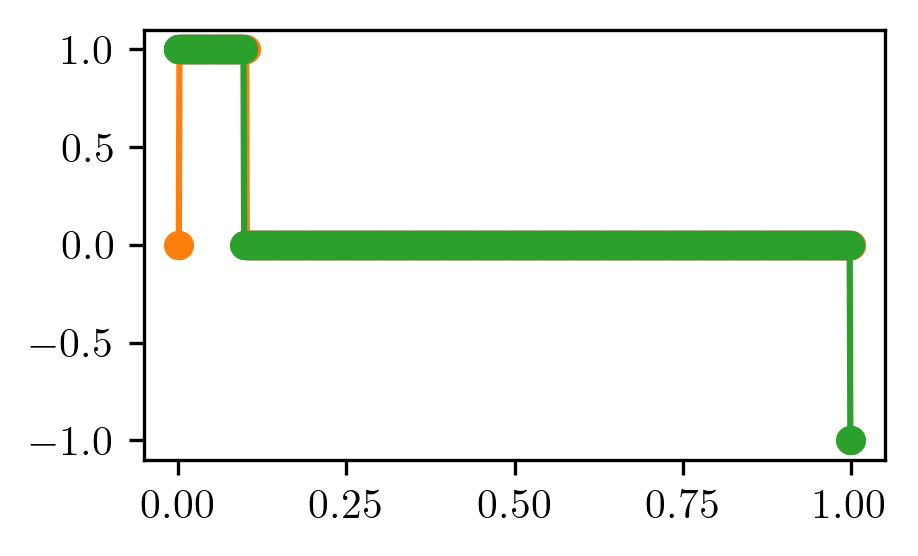

In [24]:
fig, axg1 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
fig, axs1 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
fig, axg2 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
fig, axs2 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))

for n in [10, 20, 30, 1000]:
    x = np.linspace(-1, 2, 3*m, endpoint=False) + 1/2*(1/m)
    mu = np.linspace(0, 2, n, endpoint=False) #+ 1/2*(2/n)
    print(x[0], x[-1])
    print(x[0]-(-1), 2-x[-1])
    print("mu")
    print(mu[0], mu[-1])
    print(mu[0], 2-mu[-1])
    print(n)
    
    X = np.empty((3*m, n))
    for j, mu_j in enumerate(mu):
        y = pulse(x, mu_j)
        X[:, j] = y

    dx = 1/m
    Xs = smoothen(X, sigma=0.1/dx, shape=(3*m,), truncate=8, mode="wrap")
    X = X[m:-m]
    Xs = Xs[m:-m]
    x = x[m:-m]
    Ug, Sg, Vg = np.linalg.svd(X, full_matrices=False)
    Us, Ss, Vs = np.linalg.svd(Xs, full_matrices=False)

    fig, ax = plt.subplots()
    ax.plot(x, X[:, 0], "o-")
    ax.plot(x, X[:, 1], "o-")
    ax.plot(x, X[:, -1], "o-")
    #ax.set_xlim([.04, .06])
    
    Ug[:, np.mean(Ug, axis=0)<0] *= -1
    Us[:, np.mean(Us, axis=0)<0] *= -1
    if np.mean(Ug[:, 0])>np.mean(Ug[:, 1]):
        tmp = Ug[:, 0].copy()
        Ug[:, 0] = Ug[:, 1].copy()
        Ug[:, 1] = tmp.copy()
    if np.mean(Us[:, 0])>np.mean(Us[:, 1]):
        tmp = Us[:, 0].copy()
        Us[:, 0] = Us[:, 1].copy()
        Us[:, 1] = tmp.copy()
    axg1.plot(x, Ug[:, 0], ".-", ms=1, label="$n_{\mu}=%i$"%n)
    axs1.plot(x, Us[:, 0], ".-", ms=1, label="$n_{\mu}=%i$"%n)
    axg2.plot(x, Ug[:, 1], ".-", ms=1, label="$n_{\mu}=%i$"%n)
    axs2.plot(x, Us[:, 1], ".-", ms=1, label="$n_{\mu}=%i$"%n)
for ax in [axg1, axs1, axg2, axs2]:
    ax.set_xticks(np.linspace(-1., 1., 21, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(-.2, .2, 21, endpoint=True), minor=True)
    ax.grid(True, which='minor', linestyle='--', lw=.25)
    ax.grid(True, which='major', linestyle='-')
    ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.15, 0.15)
#axs1.set_ylim(-0.15, 0.15)
plt.show()